In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os.path

In [2]:
outdir = "output/"
label = "4C1971"
if not os.path.exists(outdir):
    os.makedirs(outdir)
logfile = os.path.join(outdir, label+"-fitlog.txt")
infile = "4C1971_G235H_NRS1_NRS2_s3d.fits"

In [3]:
from q3dfit.q3din import q3din
q3di = q3din(infile, label, outdir=outdir, logfile=logfile)

In [4]:
q3di.argsreadcube = {"wmapext": True}
cube = q3di.load_cube()

Cube: No wavelength units in header; using micron
Size of data cube: [ 70 , 83 , 3815 ]
Wavelength range: [ 1.660198 , 3.170542 ]  micron
Input flux units:  MJy/sr
Input wave units:  micron
Output flux units:  erg/s/cm2/micron
Output wave units:  micron
NB: q3dfit uses output units for internal calculations.


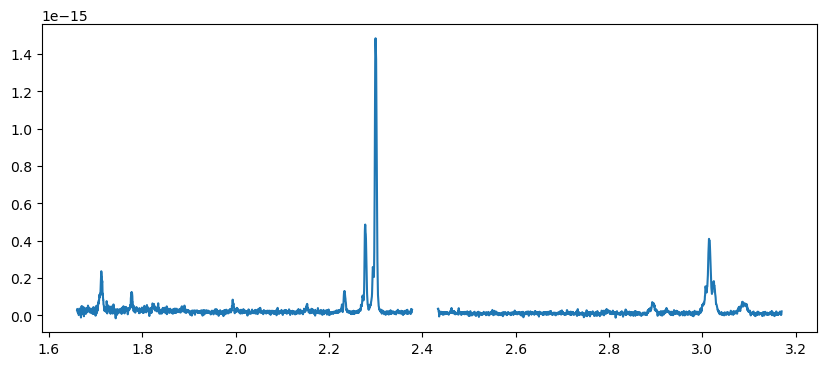

In [5]:
fig = plt.figure(figsize=[10,4])
spec_test = cube.specextract(22, 36, radius=0)

In [6]:
cube.convolve(2.5)

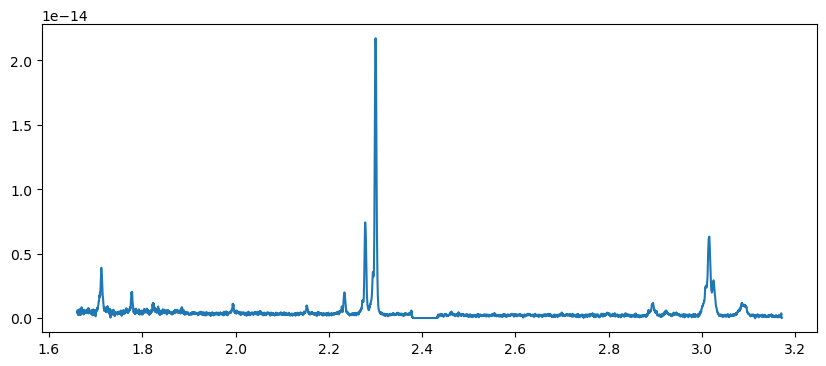

In [7]:
fig = plt.figure(figsize=[10,4])
spec_conv = cube.specextract(22, 36, radius=0)

In [8]:
cube.writefits(os.path.join(outdir, "4C1971_conv.fits"))
q3di.infile = os.path.join(outdir, "4C1971_conv.fits")
q3di.argsreadcube = {"wmapext": True}
cube = q3di.load_cube()

Cube: No wavelength units in header; using micron
Size of data cube: [ 70 , 83 , 3815 ]
Wavelength range: [ 1.660198 , 3.170542 ]  micron
Input flux units:  MJy/sr
Input wave units:  micron
Output flux units:  erg/s/cm2/micron
Output wave units:  micron
NB: q3dfit uses output units for internal calculations.


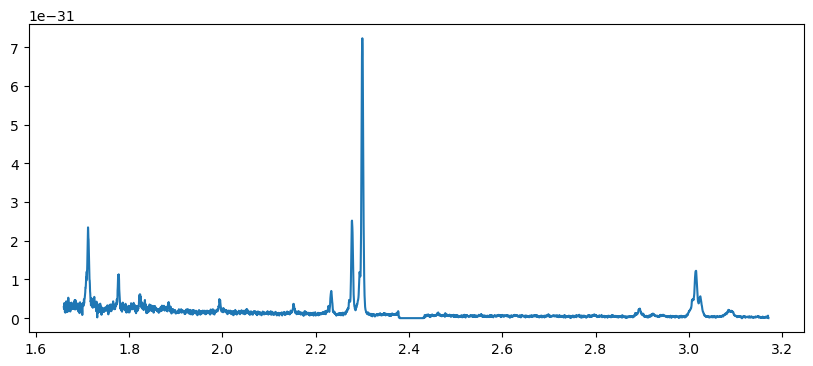

In [9]:
fig = plt.figure(figsize=[10,4])
spec_conv = cube.specextract(22, 36, radius=0)

In [10]:
q3di.name = label
q3di.zsys_gas = 3.5892
q3di.fitrange = [2.2, 2.35]

makeqsotempate: using peak spaxel in white light as center


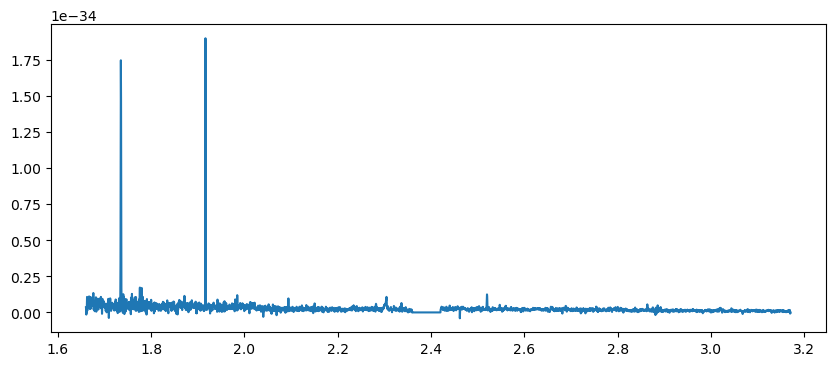

In [11]:
qsotemplate = os.path.join(outdir, 'nirspec-j1652-quasar-template.npy')
fig = plt.figure(figsize=[10,4])
cube.makeqsotemplate(qsotemplate, radius=0., norm=5e3)

In [12]:
lines = ['Hbeta', '[OIII]4959', '[OIII]5007']

In [13]:
q3di.init_linefit(lines, linetie='[OIII]5007', maxncomp=3)
q3di.__dict__.keys()

dict_keys(['argsreadcube', 'cutrange', 'infile', 'fitrange', 'label', 'logfile', 'name', 'outdir', 'spect_convol', 'vacuum', 'zsys_gas', 'datext', 'varext', 'dqext', 'vormap', 'docontfit', 'dolinefit', 'ncols', 'nrows', 'cubedim', 'lines', 'argscheckcomp', 'argslineinit', 'argslinefit', 'argslinelist', 'checkcomp', 'fcncheckcomp', 'fcnlineinit', 'maxncomp', 'peakinit', 'perror_errspecwin', 'perror_residwin', 'perror_useresid', 'siglim_gas', 'linetie', 'ncomp', 'siginit_gas', 'zinit_gas'])

In [14]:
for i in lines:
    q3di.zinit_gas[i][:,:,2] = 3.5956
    q3di.zinit_gas[i][:,:,1] = 3.5816

In [1]:
0.486 * (1 + 3.5892)
2.30 / 0.5007 - 1

3.5935690033952463

In [16]:
q3di.siglim_gas = np.array([40., 2000.])

In [17]:
q3di.argscheckcomp['sigcut'] = 3.
q3di.argscheckcomp['ignore']= ['Hbeta']

In [18]:
q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}

In [19]:
q3di.argslinefit['ftol'] = 1.e-10
q3di.argslinefit['gtol'] = 1.e-10
q3di.argslinefit['xtol'] = 1.e-10
q3di.argslinefit['x_scale'] = 'jac'
q3di.argslinefit['tr_solver'] = 'lsmr'

In [20]:
q3di.init_contfit('fitqsohost')
q3di.__dict__.keys()

dict_keys(['argsreadcube', 'cutrange', 'infile', 'fitrange', 'label', 'logfile', 'name', 'outdir', 'spect_convol', 'vacuum', 'zsys_gas', 'datext', 'varext', 'dqext', 'vormap', 'docontfit', 'dolinefit', 'ncols', 'nrows', 'cubedim', 'lines', 'argscheckcomp', 'argslineinit', 'argslinefit', 'argslinelist', 'checkcomp', 'fcncheckcomp', 'fcnlineinit', 'maxncomp', 'peakinit', 'perror_errspecwin', 'perror_residwin', 'perror_useresid', 'siglim_gas', 'linetie', 'ncomp', 'siginit_gas', 'zinit_gas', 'fcncontfit', 'argscontfit', 'argsconvtemp', 'decompose_qso_fit', 'decompose_ppxf_fit', 'dividecont', 'ebv_star', 'fcnconvtemp', 'forcefloat64', 'keepstarz', 'maskwidths', 'maskwidths_def', 'masksig_secondfit', 'nolinemask', 'nomaskran', 'startempfile', 'startempvac', 'tweakcntfit', 'siginit_stars', 'zinit_stars'])

In [21]:
q3di.maskwidths_def = 2000.

In [22]:
q3di.argscontfit['qsoxdr'] = qsotemplate
q3di.argscontfit['qsoord'] = 2
q3di.argscontfit['hostord'] = 2
q3di.decompose_qso_fit = True

In [23]:
argslmfit = dict()
argslmfit['ftol'] = 1.e-12
argslmfit['gtol'] = 1.e-12
argslmfit['xtol'] = 1.e-12
argslmfit['x_scale'] = 'jac'
argslmfit['tr_solver'] = 'lsmr'
#argslmfit['epsfcn'] = 1.e-15

q3di.argscontfit['argslmfit'] = argslmfit

In [24]:
q3di_npy = 'q3di.npy'
np.save(os.path.join(outdir, q3di_npy), q3di)

In [27]:
from q3dfit.q3df import q3dfit
q3dfit(os.path.join(outdir, q3di_npy), cols=[0,70], rows=[0,83], ncores=22, nocrash=True)

Core 2: # spaxels fit=271
Core 5: # spaxels fit=271
Core 7: # spaxels fit=271
Core 11: # spaxels fit=272
Core 12: # spaxels fit=271
Core 21: # spaxels fit=271
Core 4: # spaxels fit=271
Core 9: # spaxels fit=271
Core 22: # spaxels fit=272
Core 14: # spaxels fit=271
Core 18: # spaxels fit=271
Core 10: # spaxels fit=271


Traceback (most recent call last):
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/q3df_helperFunctions.py", line 225, in <module>
    q3df_multiCore(rank, size, inobj, cols, rows, onefit, quiet)
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/q3df_helperFunctions.py", line 172, in q3df_multiCore
    execute_fitloop(nspax_thisCore, colarr, rowarr, cube, q3di,
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/q3df_helperFunctions.py", line 63, in execute_fitloop
    fitloop(ispax, colarr, rowarr, cube, q3di, linelist, specConv,
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/fitloop.py", line 205, in fitloop
    q3do_init = fitspec(cube.wave, flux, err, dq, zstar, listlines,
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/fitspec.py", line 423, in fitspec
    continuum = gdflux.copy()
AttributeError: 'int' object has no attrib

Core 13: # spaxels fit=271
Core 17: # spaxels fit=271
Core 19: # spaxels fit=271
Core 3: # spaxels fit=271
Core 20: # spaxels fit=271
Core 1: # spaxels fit=271
Core 16: # spaxels fit=271
Core 8: # spaxels fit=271
Core 15: # spaxels fit=271
Core 6: # spaxels fit=271


Traceback (most recent call last):
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/q3df_helperFunctions.py", line 225, in <module>
    q3df_multiCore(rank, size, inobj, cols, rows, onefit, quiet)
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/q3df_helperFunctions.py", line 172, in q3df_multiCore
    execute_fitloop(nspax_thisCore, colarr, rowarr, cube, q3di,
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/q3df_helperFunctions.py", line 63, in execute_fitloop
    fitloop(ispax, colarr, rowarr, cube, q3di, linelist, specConv,
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/fitloop.py", line 205, in fitloop
    q3do_init = fitspec(cube.wave, flux, err, dq, zstar, listlines,
  File "/home/daniel/micromamba/envs/q3dfit38/lib/python3.8/site-packages/q3dfit/fitspec.py", line 423, in fitspec
    continuum = gdflux.copy()
AttributeError: 'int' object has no attrib

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from q3dfit.q3dpro import OneLineData, LineData
from q3dfit import q3dutil

# q3di saved configuration file
filename_q3di = "input/q3di.npy"

# Open
q3di = q3dutil.get_q3dio(filename_q3di)

# -- Generating a map that will be used as a base image to locate spaxels --
# linedata
linedat = LineData(q3di)
# Read [OIII]
o3data = OneLineData(linedat, '[OIII]5007')
# Total [OIII] flux
# It can be any image with the same cube spatial size, but notice that I
# transposed the map generated from q3dfit 
Fo3_tot = np.nansum(o3data.flux.T, axis=0)
Fo3_tot

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

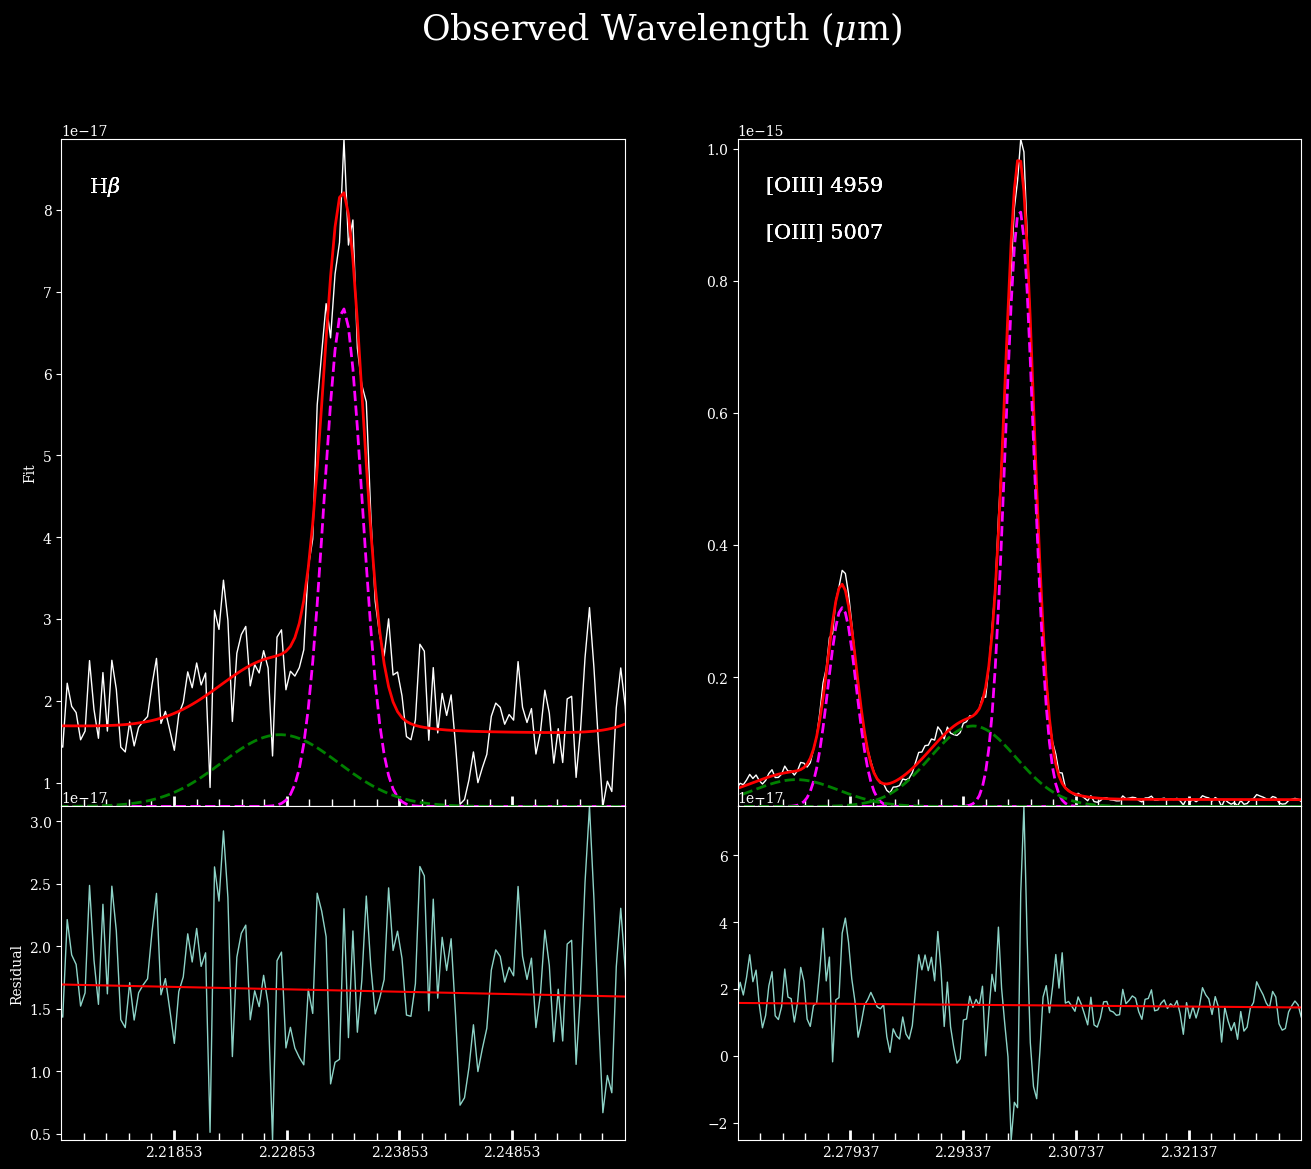

In [27]:
%matplotlib inline 
#cols, rows = loc[0], loc[1] 
# q3di saved configuration file
filename_q3di = "input/q3di.npy"
# Open
q3di = q3dutil.get_q3dio(filename_q3di)
# print(q3di.__dict__)
cols, rows = 20, 35 
from q3dfit.q3dout import load_q3dout 
q3do = load_q3dout(q3di, cols, rows) 
# print(q3do.__dict__)
argsplotline = dict() 
argsplotline['nx'] = 2 
argsplotline['ny'] = 1 
argsplotline['line'] = ['Hbeta', '[OIII]5007'] 
argsplotline['size'] = [0.05, 0.07] 
plt.close('all') 
#%matplotlib qt 
q3do.plot_line(q3di,plotargs=argsplotline)